<a href="https://colab.research.google.com/github/hbisgin/DeepLearning/blob/main/DL_11_Q.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
import urllib.request
from matplotlib.pyplot import imshow






In [3]:
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True)
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True)
x_example, y_example = mnist_data_train[0]
type(x_example)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.71MB/s]


PIL.Image.Image

In [4]:
print(x_example.mode)

L


In [5]:
x_example.size

(28, 28)

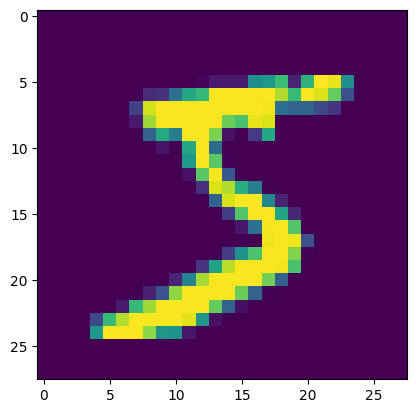

In [6]:
imshow(x_example) #it seems colorful, but it is because of matplotlib not because it is a color image!

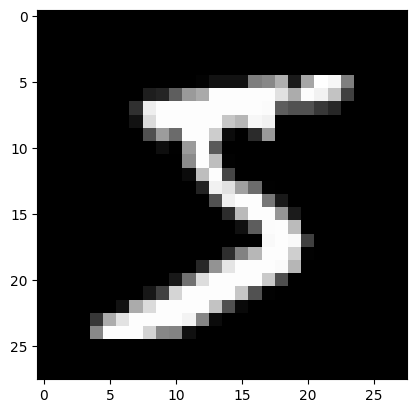

In [7]:
imshow(x_example, cmap='gray')

In [10]:
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
x_example, y_example = mnist_data_train[0]
print(x_example.shape)

torch.Size([1, 28, 28])


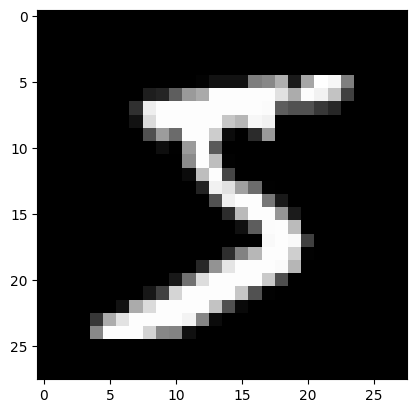

In [11]:
imshow(x_example[0,:], cmap='gray')

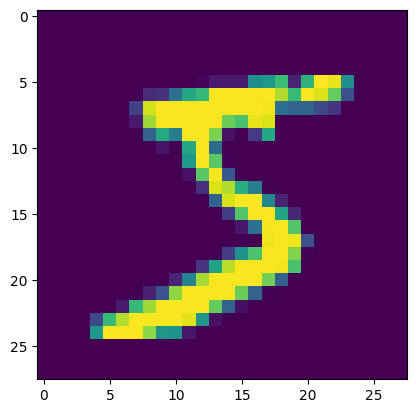

In [12]:
imshow(x_example[0,:])

In [13]:
x_example.shape

torch.Size([1, 28, 28])

In [14]:
x_as_color = torch.stack([x_example[0,:], x_example[0,:], x_example[0,:]], dim=0)
print(x_as_color.shape)

torch.Size([3, 28, 28])


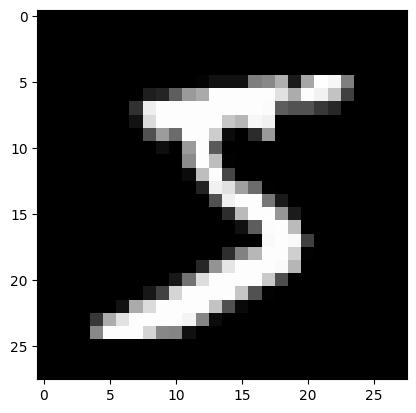

In [15]:
imshow(x_as_color.permute(1,2,0))

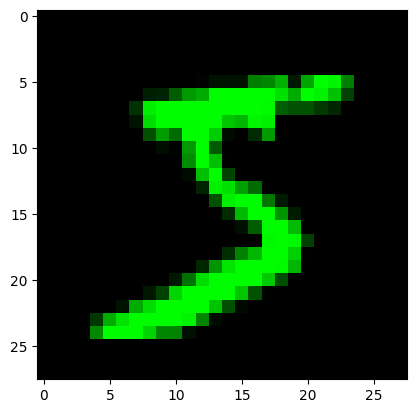

In [16]:
x_as_color = torch.stack([x_example[0,:], x_example[0,:], x_example[0,:]])
x_as_color[0,:] = 0 #No Red
#Leaving green alone
x_as_color[2,:] = 0 #No Blue
imshow(x_as_color.permute(1,2,0))

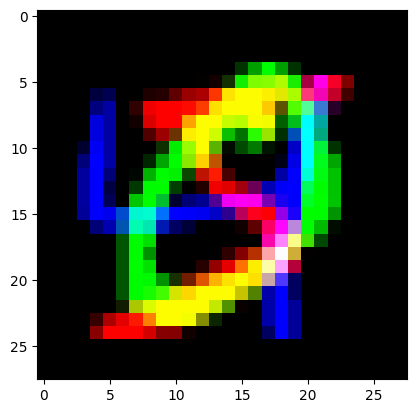

In [17]:
#grab 3 images
x1, x2, x3 = mnist_data_train[0], mnist_data_train[1], mnist_data_train[2]
#drop the labels
x1, x2, x3 = x1[0], x2[0], x3[0]
x_as_color = torch.stack([x1[0,:], x2[0,:], x3[0,:]], dim=0)
imshow(x_as_color.permute(1,2,0))

What happens if we shuffle the data within a channel?

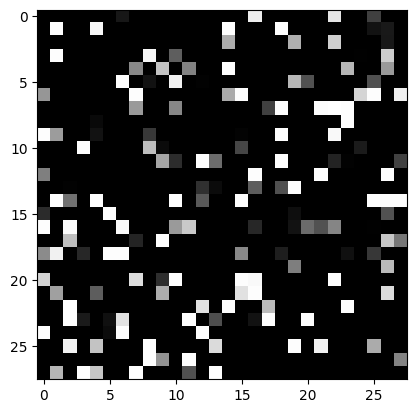

In [18]:
rand_order = torch.randperm(x_example.shape[1] * x_example.shape[2])
x_shuffled = x_example.view(-1)[rand_order].view(x_example.shape)
imshow(x_shuffled[0,:], cmap='gray')

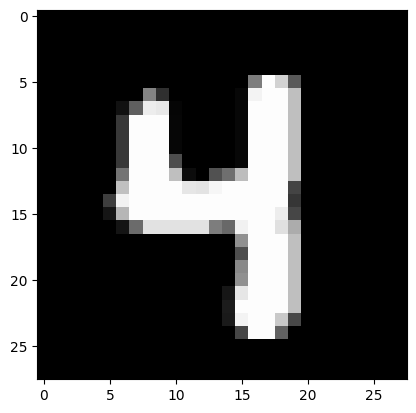

In [22]:
from scipy.signal import convolve
img_indx = 58
img = mnist_data_train[img_indx][0][0,:]
plt.imshow(img, vmin=0, vmax=1, cmap='gray')

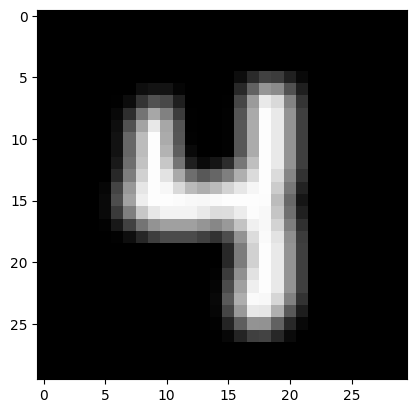

In [23]:
blur_filter = np.asarray([[1,1,1],
                          [1,1,1],
                          [1,1,1]
                         ])/9.0

blurry_img = convolve(img, blur_filter)
plt.imshow(blurry_img, vmin=0, vmax=1, cmap='gray')
plt.show()

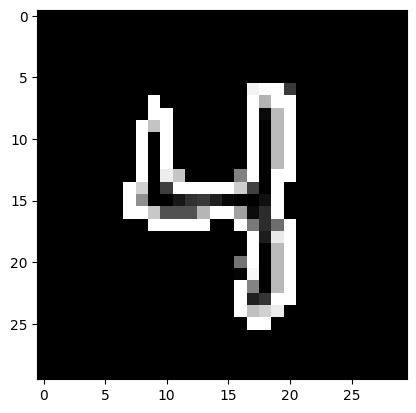

In [24]:
#We can find edges by focusing on the difference between a pixel, and its neighbors
edge_filter = np.asarray([[-1,-1,-1],
                          [-1, 8,-1],
                          [-1,-1,-1]
                         ])


edge_img = convolve(img, edge_filter)
plt.imshow(edge_img, vmin=0, vmax=1, cmap='gray')
plt.show()

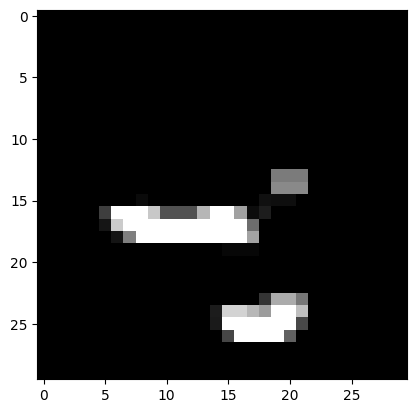

In [25]:
#We could look for only horizontal edges
h_edge_filter = np.asarray([[-1,-1,-1],
                          [0, 0,0],
                          [1, 1, 1]
                         ])


h_edge_img = convolve(img, h_edge_filter)
plt.imshow(h_edge_img, vmin=0, vmax=1, cmap='gray')
plt.show()

PIL image size: (256, 256)
Tensor shape: torch.Size([1, 256, 256])
Tensor dtype: torch.float32
Min/Max: 0.0 1.0


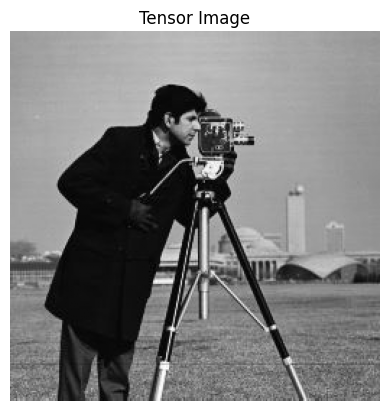

In [8]:
# You can define a transform pipeline with Compose
transform = transforms.Compose([
    transforms.ToTensor()
])

# --- Read image with PIL ---
img = Image.open("/content/drive/MyDrive/DATA/cameraman.jpg").convert("L")

print("PIL image size:", img.size)


x = transform(img)# We are calling our transform

print("Tensor shape:", x.shape)
print("Tensor dtype:", x.dtype)
print("Min/Max:", x.min().item(), x.max().item())

# --- Visualize ---
plt.imshow(x.squeeze(), cmap="gray") #using squeeze here to reduce the dimension and make it fit for matplotlib
plt.title("Tensor Image")
plt.axis("off")
plt.show()

#let's do some image processing

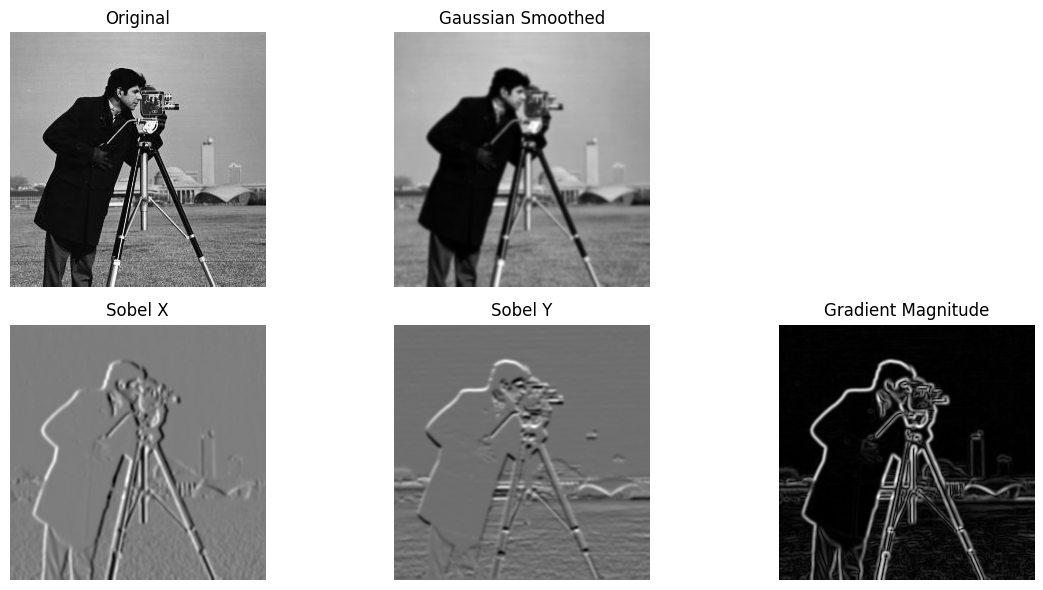

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter



# Gaussian smoothing (denoising) ---
smoothed = gaussian_filter(img, sigma=1.2)

# Sobel filters
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

grad_x = convolve2d(smoothed, sobel_x, mode="same", boundary="symm")
grad_y = convolve2d(smoothed, sobel_y, mode="same", boundary="symm")

# Gradient magnitude
edges = np.sqrt(grad_x**2 + grad_y**2)

# Let's visualiza
plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(smoothed, cmap="gray")
plt.title("Gaussian Smoothed")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(grad_x, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(grad_y, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(edges, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

#Can you read lenna.jpg and perform the same filtering steps for it?

PIL image size: (512, 512)


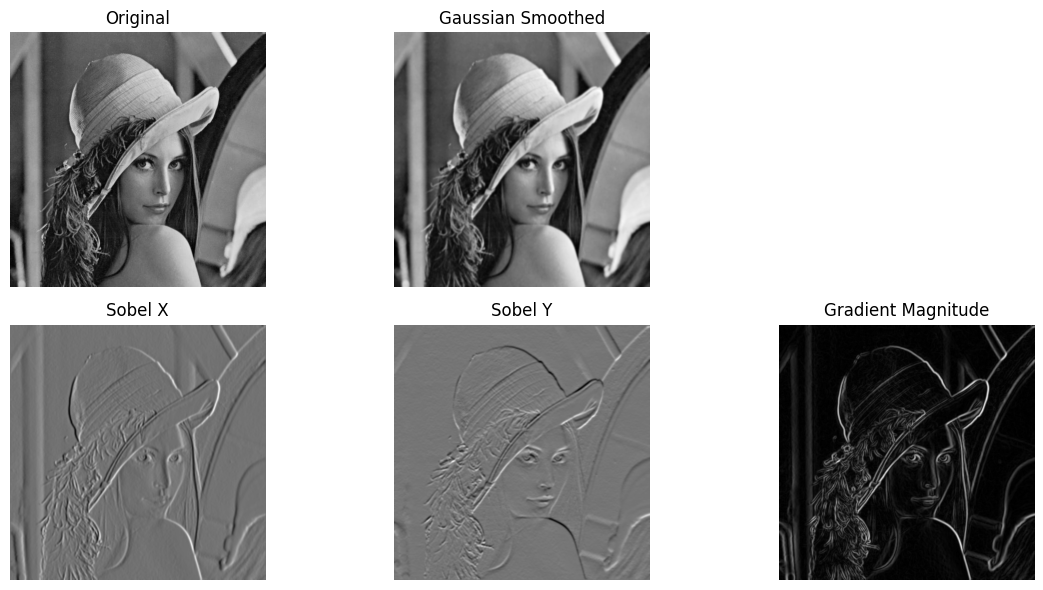